# 04 — Fusion Model, Evaluation & Backtesting
**P08: Stock Market Sentiment and Price Movement Predictor**

This notebook:
1. Loads price features and generates synthetic daily sentiment scores.
2. Merges them on the date axis.
3. Runs **three experiments** (Price-Only LSTM, Sentiment-Only MLP, Fusion LSTM).
4. Compares Accuracy & AUC-ROC in a bar chart.
5. Generates a per-stock sentiment ↔ 1-day return correlation heatmap.
6. **Backtests** the Fusion model on 2 stocks (AAPL & TSLA) side by side.
7. Saves all results to `results/`.

---
## 0 · Setup

In [23]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.config import STOCKS, LOOKBACK, SEED, RESULTS_DIR
from src.data_pipeline import load_all_stocks
from src.feature_engineering import (
    add_features, add_target, create_sequences,
    split_data, scale_features,
)
from src.lstm_model import train_lstm, evaluate_lstm
from src.fusion_model import (
    merge_sentiment,
    build_fusion_features,
    train_sentiment_mlp,
    evaluate_mlp,
    run_experiments,
    plot_experiment_comparison,
    compute_sentiment_correlation,
)
from sklearn.utils.class_weight import compute_class_weight
from src.backtesting import (
    backtest, plot_backtest, print_summary, compare_stocks,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

Device: cpu


---
## 1 · Load Stock Data

In [25]:
stock_data = load_all_stocks()
print(f'Loaded {len(stock_data)} tickers: {list(stock_data.keys())}')


═══════════════════════════════════════════════════════
  Loading 5 stocks: AAPL, MSFT, GOOGL, AMZN, TSLA
═══════════════════════════════════════════════════════

[CACHE]  AAPL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AAPL_ohlcv.csv
[CACHE]  MSFT — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\MSFT_ohlcv.csv
[CACHE]  GOOGL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\GOOGL_ohlcv.csv
[CACHE]  AMZN — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AMZN_ohlcv.csv
[CACHE]  TSLA — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\TSLA_ohlcv.csv

[INFO]  Loaded 5 tickers successfully.

Loaded 5 tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']


---
## 2 · Generate / Load Daily Sentiment Scores

If you have already run `03_finbert_sentiment.ipynb` and saved real scores,  
load them here.  Otherwise we generate **synthetic sentiment** for a full  
end-to-end demonstration.

> **Tip:** Replace the synthetic block below with real FinBERT output once  
> notebook 03 has been executed.

In [26]:
# Load real FinBERT scores if available; otherwise generate synthetic daily sentiment
SENTIMENT_PATH = os.path.join(RESULTS_DIR, 'daily_sentiment.csv')
if os.path.exists(SENTIMENT_PATH):
    sentiment_daily = pd.read_csv(SENTIMENT_PATH, index_col=0, parse_dates=True)
    # Ensure column name matches the pipeline expectation: use 'daily_sentiment'
    if 'sentiment_score' in sentiment_daily.columns:
        sentiment_daily = sentiment_daily.rename(columns={'sentiment_score': 'daily_sentiment'})
    sentiment_daily.index = pd.to_datetime(sentiment_daily.index).date
    print(f"Loaded real FinBERT scores from {SENTIMENT_PATH}")
    print(f"Sentiment range: {sentiment_daily['daily_sentiment'].min():.3f} – {sentiment_daily['daily_sentiment'].max():.3f}")
    print(f"Dates: {sentiment_daily.index.min()} → {sentiment_daily.index.max()}")
else:
    print("WARN: daily_sentiment.csv not found. Using synthetic scores.")
    print("      Run 03_finbert_sentiment.ipynb first to get real FinBERT scores.")
    np.random.seed(SEED)
    date_range = pd.date_range('2019-01-01', '2024-12-31', freq='B')
    sentiment_daily = pd.DataFrame({
        'daily_sentiment': np.clip(np.random.normal(0.1, 0.3, len(date_range)), -1, 1)
    }, index=date_range.date)
    print(f"Sentiment range: {sentiment_daily['daily_sentiment'].min():.3f} – {sentiment_daily['daily_sentiment'].max():.3f}")
    print(f"Dates: {sentiment_daily.index.min()} → {sentiment_daily.index.max()}")

WARN: daily_sentiment.csv not found. Using synthetic scores.
      Run 03_finbert_sentiment.ipynb first to get real FinBERT scores.
Sentiment range: -0.872 – 1.000
Dates: 2019-01-01 → 2024-12-31


---
## 3 · Merge Demo — Price + Sentiment for One Stock

In [27]:
demo_ticker = 'AAPL'
demo_df = add_features(stock_data[demo_ticker].copy())
demo_df = add_target(demo_df)
demo_merged = merge_sentiment(demo_df, sentiment_daily)

print(f'\nMerged columns: {list(demo_merged.columns)}')
demo_merged[['Close', 'daily_return', 'RSI_14', 'sentiment_score', 'target']].tail()

[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 805 (54.1%)  |  ↓ 683 (45.9%)  |  Total 1488
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)

Merged columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'daily_return', 'return_std_20', 'RSI_14', 'MACD_12_26_9', 'MACDs_12_26_9', 'MACDh_12_26_9', 'target', 'sentiment_score']


,Close,daily_return,RSI_14,sentiment_score,target
Date,,,,,
2024-12-20,253.107361,0.018816,72.334176,0.547807,1
2024-12-23,253.883118,0.003065,73.085648,0.018663,1
2024-12-24,256.797211,0.011478,75.750286,0.093590,1
2024-12-26,257.612732,0.003176,76.452886,-0.627272,0
2024-12-27,254.201355,-0.013242,67.626231,0.365214,0


---
## 4 · Run All Three Experiments

| # | Experiment | Features |
|---|---|---|
| 1 | Price-Only LSTM | OHLCV + technical indicators |
| 2 | Sentiment-Only MLP | daily_sentiment score |
| 3 | Fusion LSTM | Price features + sentiment_score |

In [28]:
results_df = run_experiments(
    stock_data, sentiment_daily,
    lookback=LOOKBACK, device=device,
)


── Preparing AAPL ──
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 805 (54.1%)  |  ↓ 683 (45.9%)  |  Total 1488
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)
[SCALE]  Scaled 1 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 1)  |  y (1458,)  (lookback=30, features=1)
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)
[SCALE]  Scaled 12 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 12)  |  y (1458,)  (lookback=30, features=12)

── Preparing MSFT ──
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 802 (53.9%)  |  ↓ 686 (46.1%)  |  Total 1488
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)
[SCALE]  Scaled 1 columns with MinMaxS

---
## 5 · Results Table

In [29]:
results_df.style.format({'Accuracy': '{:.4f}', 'AUC-ROC': '{:.4f}'})

,Experiment,Accuracy,AUC-ROC
0,Price-Only LSTM,0.5265,0.5155
1,Sentiment-Only MLP,0.6261,0.6709
2,Fusion LSTM (Price+Sent),0.5265,0.5029


---
## 6 · Comparison Bar Chart

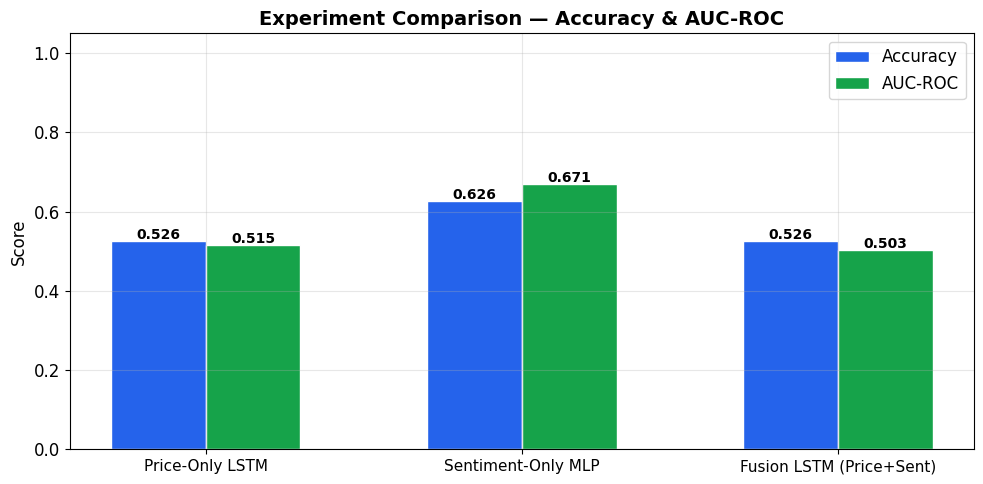

In [30]:
fig = plot_experiment_comparison(results_df)
plt.show()

---
## 7 · Sentiment ↔ 1-Day Return Correlation Heatmap

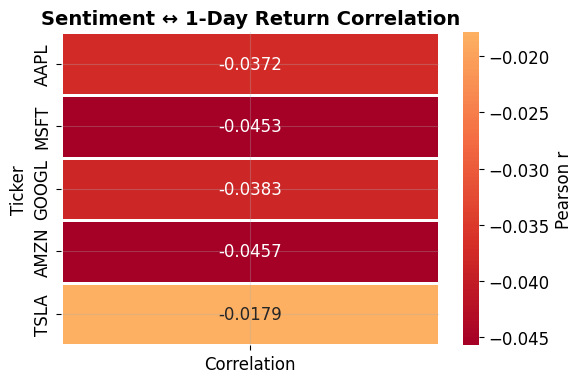

,Correlation
Ticker,
AAPL,-0.0372
MSFT,-0.0453
GOOGL,-0.0383
AMZN,-0.0457
TSLA,-0.0179


In [31]:
corr_df, fig_hm = compute_sentiment_correlation(stock_data, sentiment_daily)
plt.show()
corr_df

---
## 8 · Detailed Fusion Inspection

Train the fusion model on a single stock and inspect predictions.

In [32]:
# Build fusion features for AAPL only
X_f, y_f, feat_cols = build_fusion_features(
    stock_data['AAPL'], sentiment_daily, lookback=LOOKBACK
)
sp = split_data(X_f, y_f)

print(f'\nFeature columns ({len(feat_cols)}):')
for i, c in enumerate(feat_cols, 1):
    print(f'  {i:>2}. {c}')

[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 805 (54.1%)  |  ↓ 683 (45.9%)  |  Total 1488
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)
[SCALE]  Scaled 12 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 12)  |  y (1458,)  (lookback=30, features=12)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)

Feature columns (12):
   1. Close
   2. High
   3. Low
   4. Open
   5. Volume
   6. daily_return
   7. return_std_20
   8. RSI_14
   9. MACD_12_26_9
  10. MACDs_12_26_9
  11. MACDh_12_26_9
  12. sentiment_score


In [33]:
# Train fusion LSTM on AAPL
model_fused, hist_fused = train_lstm(
    sp['X_train'], sp['y_train'],
    sp['X_val'], sp['y_val'],
    device=device,
)

# Evaluate
eval_fused = evaluate_lstm(model_fused, sp['X_test'], sp['y_test'], device=device)


═════════════════════════════════════════════════════════════════
  Training LSTMClassifier  |  device=cpu  |  epochs=30  lr=0.001
  warmup=5  patience=7  batch=32
═════════════════════════════════════════════════════════════════

  Epoch   1/30  │  Train Loss 0.6502  │  Val Loss 0.6507  │  Val Acc 0.4886  │  LR 0.000200
  Epoch   2/30  │  Train Loss 0.6500  │  Val Loss 0.6510  │  Val Acc 0.4886  │  LR 0.000400
  Epoch   3/30  │  Train Loss 0.6499  │  Val Loss 0.6510  │  Val Acc 0.4886  │  LR 0.000600
  Epoch   4/30  │  Train Loss 0.6502  │  Val Loss 0.6508  │  Val Acc 0.4886  │  LR 0.000800
  Epoch   5/30  │  Train Loss 0.6499  │  Val Loss 0.6507  │  Val Acc 0.4886  │  LR 0.001000
  Epoch   6/30  │  Train Loss 0.6499  │  Val Loss 0.6510  │  Val Acc 0.4886  │  LR 0.001000
  Epoch   7/30  │  Train Loss 0.6498  │  Val Loss 0.6507  │  Val Acc 0.4886  │  LR 0.001000
  Epoch   8/30  │  Train Loss 0.6498  │  Val Loss 0.6513  │  Val Acc 0.4886  │  LR 0.001000

  ⏹  Early stopping at epoch 8 

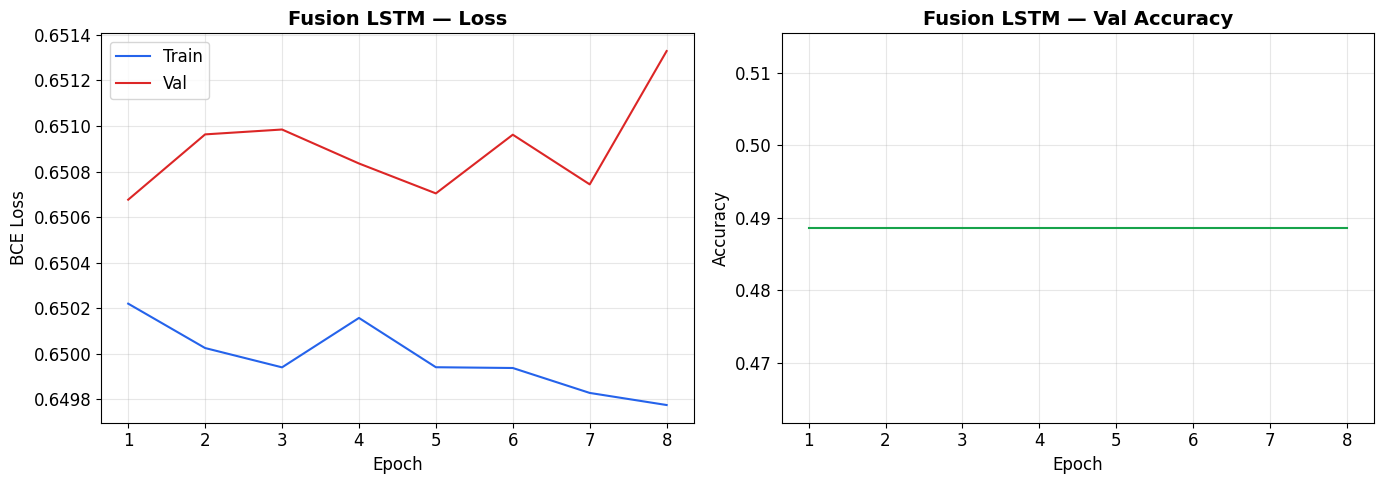

In [34]:
# Loss curve for fusion model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(hist_fused['train_loss']) + 1)

ax1.plot(ep, hist_fused['train_loss'], label='Train', color='#2563eb', lw=1.5)
ax1.plot(ep, hist_fused['val_loss'],   label='Val',   color='#dc2626', lw=1.5)
ax1.set_title('Fusion LSTM — Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.legend()

ax2.plot(ep, hist_fused['val_acc'], color='#16a34a', lw=1.5)
ax2.set_title('Fusion LSTM — Val Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

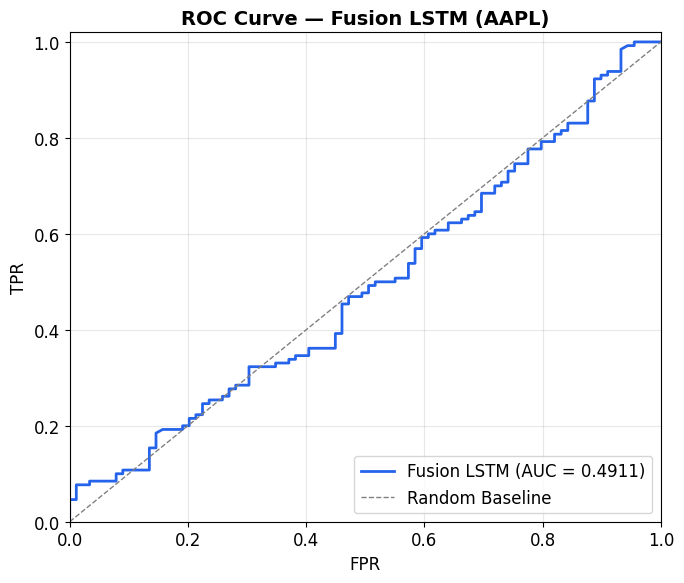

In [35]:
# ROC Curve for fusion model
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(eval_fused['fpr'], eval_fused['tpr'], color='#2563eb', lw=2,
        label=f"Fusion LSTM (AUC = {eval_fused['auc_roc']:.4f})")
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Baseline')
ax.set_title('ROC Curve — Fusion LSTM (AAPL)', fontsize=14, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## 9 · Experiment Summary

In [36]:
print('┌──────────────────────────────────────────────────┐')
print('│         Experiment Results Summary                │')
print('├──────────────────────────────────────────────────┤')
for _, row in results_df.iterrows():
    print(f"│  {row['Experiment']:<30s}  "
          f"Acc {row['Accuracy']:.4f}  AUC {row['AUC-ROC']:.4f}  │")
print('└──────────────────────────────────────────────────┘')
print(f'\nResults saved to: {os.path.join(RESULTS_DIR, "experiment_results.csv")}')

┌──────────────────────────────────────────────────┐
│         Experiment Results Summary                │
├──────────────────────────────────────────────────┤
│  Price-Only LSTM                 Acc 0.5265  AUC 0.5155  │
│  Sentiment-Only MLP              Acc 0.6261  AUC 0.6709  │
│  Fusion LSTM (Price+Sent)        Acc 0.5265  AUC 0.5029  │
└──────────────────────────────────────────────────┘

Results saved to: d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\results\experiment_results.csv


---
## 10 · Backtesting — AAPL & TSLA

Train a Fusion LSTM **per stock**, generate predictions on the test set,  
then simulate the signal-driven trading strategy and compare with Buy & Hold.

In [37]:
backtest_tickers = ['AAPL', 'TSLA']
bt_results = {}

for ticker in backtest_tickers:
    print(f"\n{'█' * 60}")
    print(f"  BACKTESTING — {ticker}")
    print(f"{'█' * 60}")
    
    # Build fusion features
    X_bt, y_bt, _ = build_fusion_features(
        stock_data[ticker], sentiment_daily, lookback=LOOKBACK,
    )
    sp_bt = split_data(X_bt, y_bt)
    
    # Train
    # Compute pos_weight and save model per-ticker to avoid overwrites
    cw_bt = compute_class_weight('balanced', classes=np.array([0, 1]), y=sp_bt['y_train'])
    pos_w_bt = torch.tensor([float(cw_bt[1])], dtype=torch.float32)
    model_bt, _ = train_lstm(
        sp_bt['X_train'], sp_bt['y_train'],
        sp_bt['X_val'],   sp_bt['y_val'],
        device=device,
        pos_weight=pos_w_bt,
        save_path=os.path.join(RESULTS_DIR, f'backtest_{ticker}.pth'),
    )
    
    # Predict on test set
    model_bt.eval()
    X_test_t = torch.tensor(sp_bt['X_test'], dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = model_bt(X_test_t).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    
    # Get the matching test-period prices
    # The test set starts at index (train+val) in the processed DataFrame
    raw_df = stock_data[ticker].copy()
    df_proc = add_features(raw_df)
    df_proc = add_target(df_proc)
    df_proc = merge_sentiment(df_proc, sentiment_daily)
    
    # Offset: lookback rows consumed by sequence creation
    total_sequences = len(X_bt)
    test_start_idx = int(total_sequences * 0.85)  # 70% + 15% = 85%
    
    # Price array aligned with test sequences
    price_start = LOOKBACK + test_start_idx
    test_prices = df_proc['Close'].values[price_start : price_start + len(preds)]
    test_dates  = df_proc.index[price_start : price_start + len(preds)]
    
    # Run backtest
    bt = backtest(
        prices=test_prices,
        predictions=preds,
        true_labels=sp_bt['y_test'],
        initial_capital=100_000,
        risk_free_rate=0.01,
        dates=pd.DatetimeIndex(test_dates),
    )
    bt_results[ticker] = bt


████████████████████████████████████████████████████████████
  BACKTESTING — AAPL
████████████████████████████████████████████████████████████
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 805 (54.1%)  |  ↓ 683 (45.9%)  |  Total 1488
[MERGE]  1488 rows after merging sentiment (nulls filled: 0)
[SCALE]  Scaled 12 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 12)  |  y (1458,)  (lookback=30, features=12)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)

═════════════════════════════════════════════════════════════════
  Training LSTMClassifier  |  device=cpu  |  epochs=30  lr=0.001
  warmup=5  patience=7  batch=32
═════════════════════════════════════════════════════════════════

  Epoch   1/30  │  Train Loss 0.6720  │  Val Loss 0.6723  │  Val Acc 0.4886  │  LR 0.000200
  Epoch   2/30  │  Train Loss 0.6708  │  Val Loss 0.6728  │  Val Acc 0.4886  │  LR 0.000400
  Epoch   3/30  │  Train Loss 0.6712  │  Val Loss 0.6725  │  Val 

---
## 11 · Backtest — Side-by-Side Comparison


┌────────────────────────────────────────────────┐
│                      AAPL                      │
├────────────────────────────────────────────────┤
│  Strategy Cumulative Return  :      +0.00%       │
│  Buy & Hold Return           :     +39.52%       │
│  Sharpe Ratio (rf=1%)        :  -629940.7883       │
│  Max Drawdown                :       0.00%       │
└────────────────────────────────────────────────┘

┌────────────────────────────────────────────────┐
│                      TSLA                      │
├────────────────────────────────────────────────┤
│  Strategy Cumulative Return  :      +0.00%       │
│  Buy & Hold Return           :    +115.35%       │
│  Sharpe Ratio (rf=1%)        :  -629940.7883       │
│  Max Drawdown                :       0.00%       │
└────────────────────────────────────────────────┘

[SAVED]  Combined plot → d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\results\backtest_plot.png


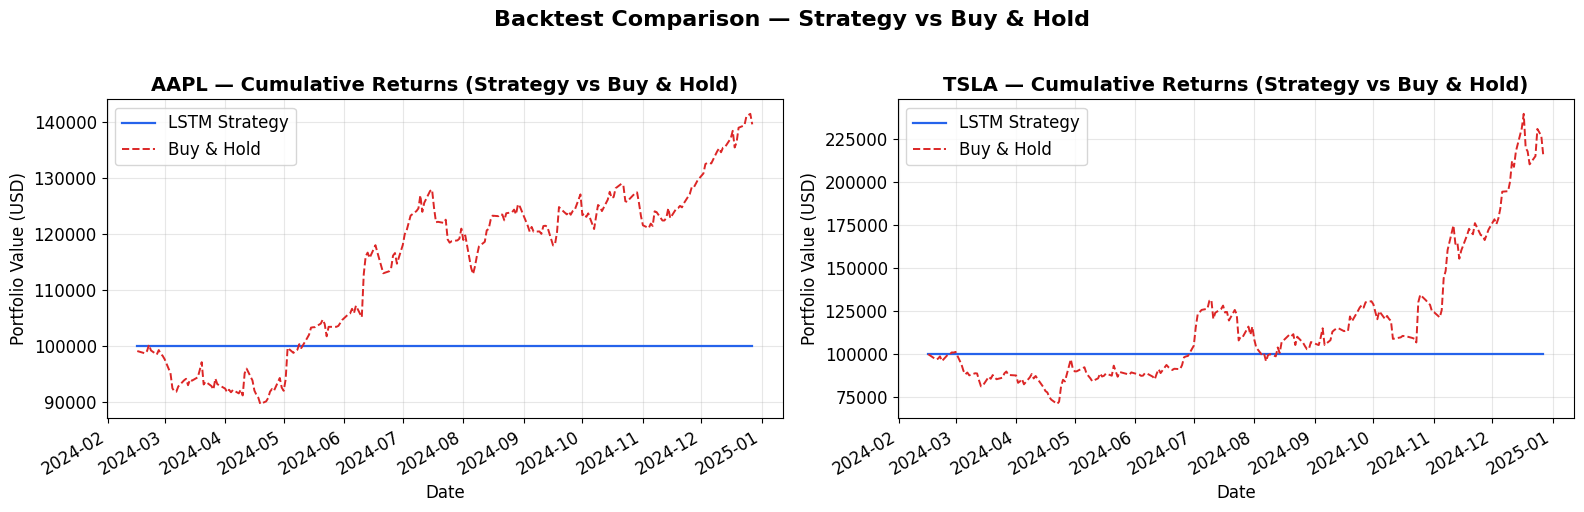


══════════════════════════════════════════════════════════════════════
  Backtest Comparison Summary
══════════════════════════════════════════════════════════════════════
Ticker Strategy Return Buy&Hold Return Sharpe Ratio Max Drawdown
  AAPL          +0.00%         +39.52% -629940.7883        0.00%
  TSLA          +0.00%        +115.35% -629940.7883        0.00%
══════════════════════════════════════════════════════════════════════



In [38]:
summary_bt = compare_stocks(bt_results, save=True)

---
## 12 · Individual Backtest Plots

[SAVED]  Plot → d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\results\backtest_AAPL.png


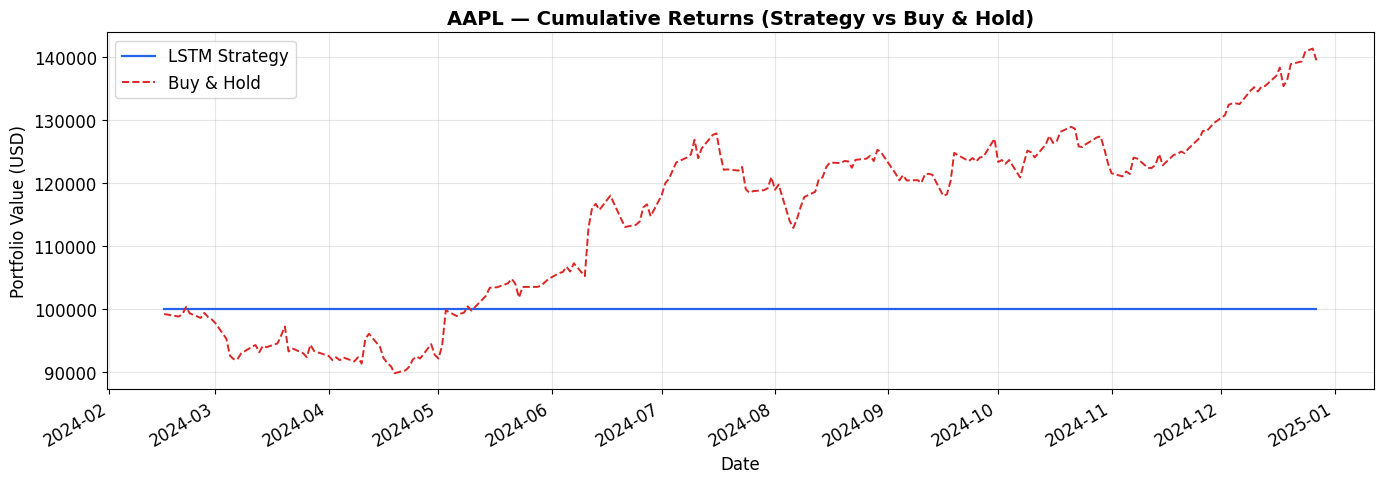

[SAVED]  Plot → d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\results\backtest_TSLA.png


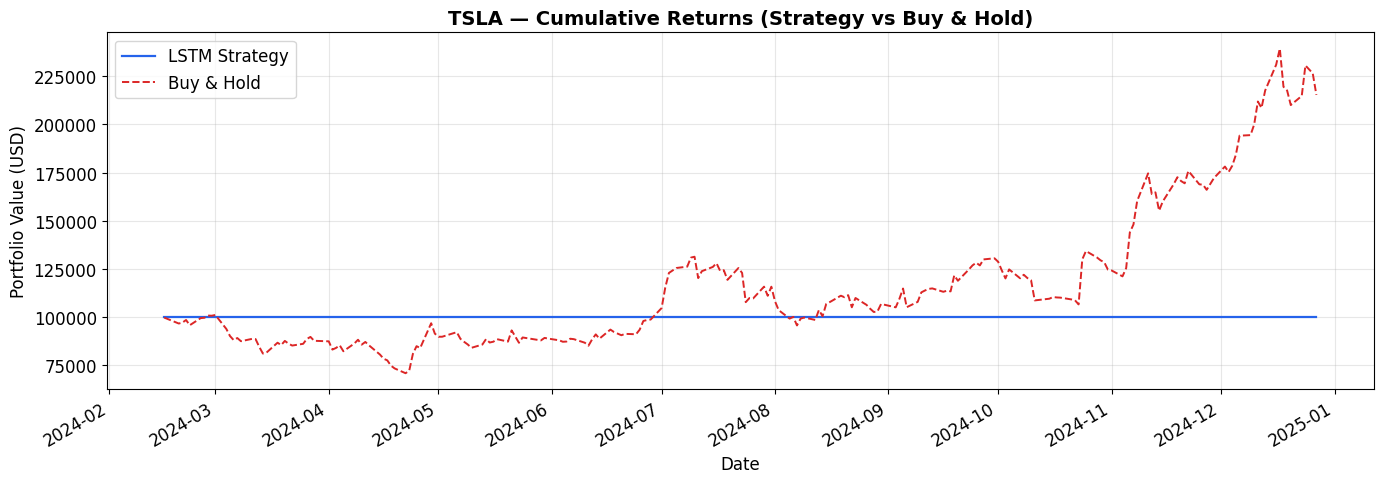

In [39]:
for ticker, res in bt_results.items():
    fig = plot_backtest(res, ticker=ticker, save=True)
    plt.show()

---
## 13 · Final Summary Table

In [40]:
summary_bt

,Ticker,Strategy Return,Buy&Hold Return,Sharpe Ratio,Max Drawdown
0,AAPL,+0.00%,+39.52%,-629940.7883,0.00%
1,TSLA,+0.00%,+115.35%,-629940.7883,0.00%


---
### ✅ All experiments & backtests complete
### Saved:
- `results/experiment_results.csv`
- `results/backtest_plot.png`
- `results/backtest_AAPL.png`
- `results/backtest_TSLA.png`

### Next Step → Build the Streamlit dashboard in `app/app.py`